<a href="https://colab.research.google.com/github/rvs0514/quant2/blob/main/wasserstein_regime_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗺️ Market Regime Clustering via Optimal Transport
### Wasserstein K-Means on Full Return Distributions

---

## 📖 The Core Idea

Most regime detection models cluster on **summary statistics** — mean return, volatility, Sharpe ratio.  
This notebook does something fundamentally different: we cluster on the **entire probability distribution** of returns.

This matters because two periods can have the **same mean and variance** but completely different distributional shapes:
- One might have fat left tails (crash risk)
- Another might be right-skewed (momentum environment)
- Another might be bimodal (bifurcated market)

Standard Euclidean k-means cannot distinguish these. **Wasserstein distance** can.

---

## 🎓 Academic Foundation

This notebook is grounded in three streams of research:

**1. Optimal Transport Theory**  
> Villani, C. (2008). *Optimal Transport: Old and New*. Springer.  
> The Wasserstein distance W₂(μ,ν) is the minimum cost of transporting mass from distribution μ to distribution ν.

**2. Wasserstein K-Means**  
> Pollard, D. (1982). *Quantization and the method of k-means*. IEEE Trans. Inf. Theory.  
> In 1D, the Wasserstein-2 barycenter of a set of distributions is simply the **pointwise mean of their quantile functions** — making K-means tractable.

**3. Distribution-Based Financial Regime Detection**  
> Marti, G. et al. (2021). *A Review of Two Decades of Correlations, Hierarchies, Networks and Clustering in Financial Markets*. Springer.  
> Regime clustering should capture the full geometry of return distributions, not just first and second moments.

---

## 🔑 Key Mathematical Insight

For **1D distributions**, the Wasserstein-2 distance has a beautiful closed form:

$$W_2(\mu, \nu)^2 = \int_0^1 \left( F_\mu^{-1}(t) - F_\nu^{-1}(t) \right)^2 dt$$

where $F^{-1}$ is the **quantile function** (inverse CDF).  
This means: the Wasserstein distance between two return distributions = the **L2 distance between their quantile functions**.

And the **Wasserstein barycenter** (the "centroid" in distribution space) of a cluster is:

$$\bar{Q}(t) = \frac{1}{n} \sum_{i=1}^n F_{\mu_i}^{-1}(t)$$

Just the **pointwise average of quantile functions** — elegant and computationally cheap.

---
**No black boxes. Every line of math is implemented from first principles.**

## 🔧 Module 0 — Setup

In [10]:
# Install dependencies
!pip install yfinance POT --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import yfinance as yf
from scipy import stats
from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
import ot                          # Python Optimal Transport (POT)
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Chart style
plt.rcParams['figure.figsize']    = (14, 5)
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size']         = 11

# Colour palette for regimes (up to 6 regimes)
REGIME_COLORS = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

print('✅ Setup complete!')

✅ Setup complete!


---
## 📥 Module 1 — Download Multi-Asset Market Data

We download **five assets** to build a rich, multivariate picture of market regimes:

| Ticker | Asset | Why |
|--------|-------|-----|
| SPY | S&P 500 ETF | Core equity exposure |
| ^VIX | Volatility Index | Fear gauge |
| TLT | 20yr Treasury ETF | Risk-off indicator |
| GLD | Gold ETF | Safe haven |
| HYG | High Yield Bond ETF | Credit risk appetite |

In [11]:
START  = '2010-01-01'
END    = '2024-12-31'
TICKERS = ['SPY', 'TLT', 'GLD', 'HYG']

print('Downloading price data...')
raw = {}
for ticker in TICKERS:
    data = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    raw[ticker] = data['Close'].squeeze()

# VIX downloaded separately (no auto_adjust)
vix_raw = yf.download('^VIX', start=START, end=END, progress=False)
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)
vix = vix_raw['Close'].squeeze()

# Build returns dataframe
prices  = pd.DataFrame(raw).dropna()
returns = prices.pct_change().dropna()

# Align VIX
vix = vix.reindex(returns.index).ffill()

spy = raw['SPY']

print(f'✅ {len(returns)} trading days: {returns.index[0].date()} → {returns.index[-1].date()}')
print(f'   Assets: {list(returns.columns)}')
returns.describe().round(4)

✅ 3772 trading days: 2010-01-05 → 2024-12-30
   Assets: ['SPY', 'TLT', 'GLD', 'HYG']


,SPY,TLT,GLD,HYG
count,3772.0000,3772.0000,3772.0000,3772.0000
mean,0.0006,0.0002,0.0003,0.0002
std,0.0107,0.0096,0.0098,0.0053
min,-0.1094,-0.0667,-0.0878,-0.0550
25%,-0.0037,-0.0057,-0.0048,-0.0018
50%,0.0007,0.0005,0.0004,0.0003
75%,0.0058,0.0058,0.0055,0.0024
max,0.0906,0.0752,0.0490,0.0655


---
## 📊 Module 2 — Rolling Empirical Distributions

### The Key Idea

Instead of asking *"what was the return on day t?"*, we ask:
*"what did the **distribution** of returns look like over the past W days?"*

For each rolling window of **W = 63 trading days** (~1 quarter), we compute the **empirical quantile function** at 100 evenly-spaced probability levels.

This gives us a **vector representation** of each window's return distribution — capturing its full shape: tails, skewness, kurtosis, bimodality — not just mean and variance.

```
Day 1–63   → distribution_1  → quantile vector q₁ ∈ ℝ¹⁰⁰
Day 2–64   → distribution_2  → quantile vector q₂ ∈ ℝ¹⁰⁰
...
Day T-63–T → distribution_T  → quantile vector q_T ∈ ℝ¹⁰⁰
```

We then cluster these vectors using **Wasserstein K-Means**.

Quantile matrix shape: (3709, 100)
Each row = 1 rolling window represented as a 100-point quantile function


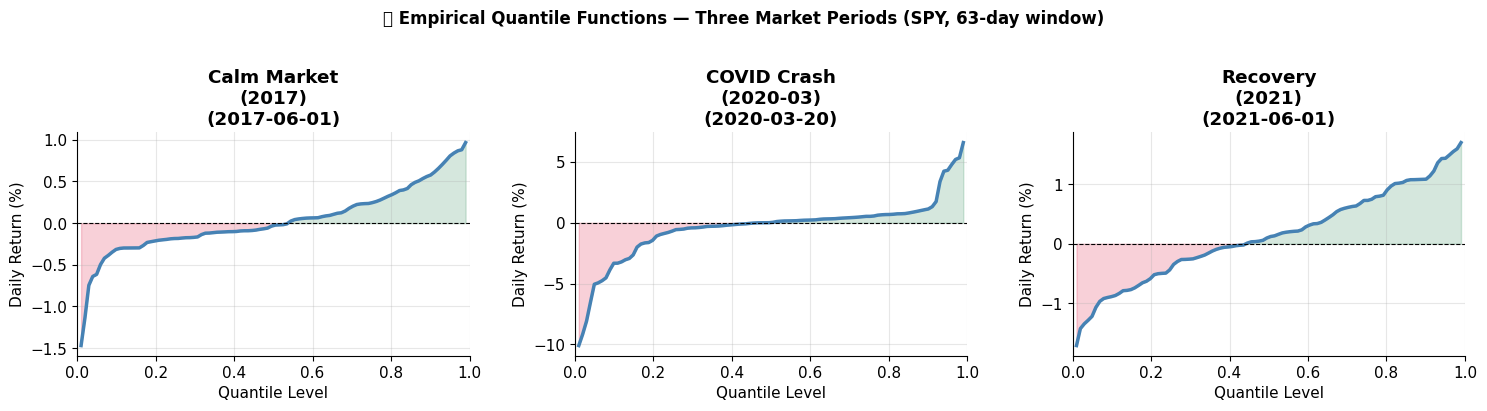


📌 Notice how different the shapes are across periods!
   Mean/vol alone would miss the tail behaviour visible in these curves.


In [12]:
WINDOW      = 63      # rolling window length (~1 quarter)
N_QUANTILES = 100     # quantile grid resolution
ASSET       = 'SPY'   # primary asset for 1D clustering (extended later)

quantile_grid = np.linspace(0.01, 0.99, N_QUANTILES)

spy_returns = returns[ASSET]

# Build quantile matrix: each row = one rolling window's quantile function
quantile_matrix = []
window_dates    = []

for i in range(WINDOW, len(spy_returns)):
    window_returns = spy_returns.iloc[i - WINDOW : i].values
    q_vec          = np.quantile(window_returns, quantile_grid)
    quantile_matrix.append(q_vec)
    window_dates.append(spy_returns.index[i])

quantile_matrix = np.array(quantile_matrix)    # shape: (T, N_QUANTILES)
window_dates    = pd.DatetimeIndex(window_dates)

print(f'Quantile matrix shape: {quantile_matrix.shape}')
print(f'Each row = 1 rolling window represented as a {N_QUANTILES}-point quantile function')

# ── Visualise a few example distributions ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

example_periods = {
    'Calm Market\n(2017)':   '2017-06-01',
    'COVID Crash\n(2020-03)': '2020-03-20',
    'Recovery\n(2021)':      '2021-06-01'
}

for ax, (label, date_str) in zip(axes, example_periods.items()):
    # Find nearest date
    idx = window_dates.get_indexer([pd.Timestamp(date_str)], method='nearest')[0]
    q   = quantile_matrix[idx]

    ax.plot(quantile_grid, q * 100, lw=2.5, color='steelblue')
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.fill_between(quantile_grid, q * 100, 0,
                    where=(q >= 0), alpha=0.2, color='seagreen')
    ax.fill_between(quantile_grid, q * 100, 0,
                    where=(q < 0),  alpha=0.2, color='crimson')
    ax.set_title(f'{label}\n({window_dates[idx].date()})', fontweight='bold')
    ax.set_xlabel('Quantile Level')
    ax.set_ylabel('Daily Return (%)')
    ax.set_xlim(0, 1)

plt.suptitle('📊 Empirical Quantile Functions — Three Market Periods (SPY, 63-day window)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n📌 Notice how different the shapes are across periods!')
print('   Mean/vol alone would miss the tail behaviour visible in these curves.')

---
## 🚚 Module 3 — Wasserstein Distance from First Principles

### What Is Optimal Transport?

Imagine two piles of sand — one representing distribution μ (e.g. 2017 calm market) and another representing ν (e.g. COVID crash). The **optimal transport problem** asks:

> *What is the minimum total "work" needed to move the sand in pile μ to match the shape of pile ν?*

Work = mass moved × distance moved. The minimum total work is the **Wasserstein distance**.

### Why Not Just Use Euclidean Distance on Returns?

Euclidean distance on histogram bins is sensitive to bin choice and doesn't respect the **geometry** of the real line. Two distributions that are "close" in the transport sense (shifted slightly) can appear "far" in Euclidean space.

Wasserstein distance respects the **ordering of values** — it knows that a return of -1% is close to -1.5%, not just to another -1% bin.

### The 1D Formula

For 1D distributions, no numerical optimisation is needed:

$$W_2(\mu, \nu) = \left( \int_0^1 |F_\mu^{-1}(t) - F_\nu^{-1}(t)|^2\, dt \right)^{1/2}$$

In practice with our quantile vectors $q_i, q_j \in \mathbb{R}^{100}$:

$$W_2(\mu_i, \mu_j) \approx \left( \frac{1}{100} \sum_{k=1}^{100} (q_i^k - q_j^k)^2 \right)^{1/2}$$


🔬 WASSERSTEIN DISTANCE DEMONSTRATION
  W2(Calm A, Crisis B)         = 0.021563  ← far apart
  W2(Calm A, Slight Shift C)   = 0.001344  ← close together
  Ratio (B is 16.0x farther than C from A)


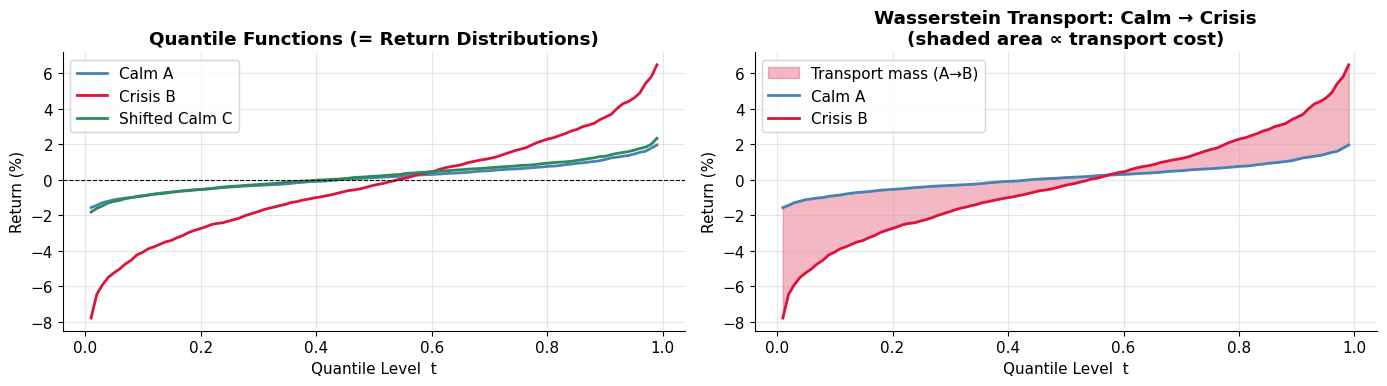

In [13]:
def wasserstein2_1d(q1, q2):
    """
    Wasserstein-2 distance between two 1D distributions
    represented as quantile function vectors.

    Theorem (Villani 2008): For 1D distributions,
    W2(μ,ν)² = ∫₀¹ (F_μ⁻¹(t) - F_ν⁻¹(t))² dt

    Discretised: W2 ≈ sqrt(mean((q1 - q2)²))
    """
    return np.sqrt(np.mean((q1 - q2) ** 2))


def wasserstein_distance_matrix(Q):
    """
    Compute full pairwise Wasserstein-2 distance matrix for a set
    of quantile function vectors Q of shape (n_windows, n_quantiles).

    Leverages the fact that W2 in 1D = L2 distance on quantile space.
    scipy.spatial.distance.cdist with metric='euclidean' is equivalent
    to W2 (up to a 1/sqrt(n_quantiles) normalisation factor).
    """
    # cdist computes L2 between all row pairs: exactly W2 on quantile functions
    D = cdist(Q, Q, metric='euclidean') / np.sqrt(Q.shape[1])
    return D


# ── Illustrate Wasserstein vs Euclidean distance ─────────────────────────────
# Three distributions: A (calm), B (crisis), C (slightly shifted calm)
np.random.seed(42)
dist_A = np.random.normal(0.001, 0.008, 1000)   # calm
dist_B = np.random.normal(-0.005, 0.030, 1000)  # crisis
dist_C = np.random.normal(0.002, 0.009, 1000)   # slightly different calm

qA = np.quantile(dist_A, quantile_grid)
qB = np.quantile(dist_B, quantile_grid)
qC = np.quantile(dist_C, quantile_grid)

w_AB = wasserstein2_1d(qA, qB)
w_AC = wasserstein2_1d(qA, qC)

print('\n🔬 WASSERSTEIN DISTANCE DEMONSTRATION')
print(f'  W2(Calm A, Crisis B)         = {w_AB:.6f}  ← far apart')
print(f'  W2(Calm A, Slight Shift C)   = {w_AC:.6f}  ← close together')
print(f'  Ratio (B is {w_AB/w_AC:.1f}x farther than C from A)')

# Plot the three quantile functions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for q, label, color in [(qA, 'Calm A', 'steelblue'),
                         (qB, 'Crisis B', 'crimson'),
                         (qC, 'Shifted Calm C', 'seagreen')]:
    axes[0].plot(quantile_grid, q * 100, lw=2, label=label, color=color)
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_title('Quantile Functions (= Return Distributions)', fontweight='bold')
axes[0].set_xlabel('Quantile Level  t')
axes[0].set_ylabel('Return (%)')
axes[0].legend()

# Visualise the "transport" between Calm A and Crisis B
axes[1].fill_between(quantile_grid, qA * 100, qB * 100,
                     alpha=0.3, color='crimson',
                     label='Transport mass (A→B)')
axes[1].plot(quantile_grid, qA * 100, lw=2, color='steelblue', label='Calm A')
axes[1].plot(quantile_grid, qB * 100, lw=2, color='crimson',   label='Crisis B')
axes[1].set_title('Wasserstein Transport: Calm → Crisis\n(shaded area ∝ transport cost)', fontweight='bold')
axes[1].set_xlabel('Quantile Level  t')
axes[1].set_ylabel('Return (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## ⚙️ Module 4 — Wasserstein K-Means: Implementation from Scratch

### Standard K-Means vs Wasserstein K-Means

| | Standard K-Means | Wasserstein K-Means |
|---|---|---|
| **Distance** | Euclidean $\|x - c\|_2$ | Wasserstein $W_2(\mu, \nu)$ |
| **Centroid** | Mean of data points | Wasserstein barycenter |
| **Space** | $\mathbb{R}^d$ | Space of probability distributions |
| **1D shortcut** | N/A | Barycenter = mean of quantile functions |

### Algorithm

```
1. Initialise K centroids (random windows)
2. REPEAT:
   a. Assign each window to the nearest centroid (W2 distance)
   b. Update each centroid = Wasserstein barycenter of its cluster
      (in 1D: pointwise mean of quantile functions)
3. UNTIL labels stop changing
```

We use **k-means++ initialisation** to avoid bad local minima.

In [14]:
def kmeans_plus_plus_init(Q, k, rng):
    """
    K-means++ initialisation in quantile/Wasserstein space.
    Spreads initial centroids to avoid bad local minima.
    Reference: Arthur & Vassilvitskii (2007)
    """
    n = len(Q)
    # Choose first centroid uniformly at random
    first = rng.integers(0, n)
    centroids = [Q[first].copy()]

    for _ in range(1, k):
        # Compute W2 distance from each point to nearest existing centroid
        dists = np.array([
            min(np.mean((q - c) ** 2) for c in centroids)
            for q in Q
        ])
        # Sample proportional to squared distance
        probs = dists / dists.sum()
        chosen = rng.choice(n, p=probs)
        centroids.append(Q[chosen].copy())

    return np.array(centroids)


def wasserstein_kmeans(Q, k=4, max_iter=100, n_init=10, seed=42):
    """
    Wasserstein K-Means clustering on empirical distributions.

    Parameters
    ----------
    Q        : np.ndarray (n_windows, n_quantiles)
               Matrix of quantile functions, one per rolling window
    k        : int — number of clusters (regimes)
    max_iter : int — maximum EM iterations
    n_init   : int — number of random restarts (keep best)
    seed     : int — random seed

    Returns
    -------
    labels    : np.ndarray (n_windows,) — cluster assignments
    centroids : np.ndarray (k, n_quantiles) — Wasserstein barycenters
    inertia   : float — total within-cluster W2² (lower = better)
    """
    best_labels    = None
    best_centroids = None
    best_inertia   = np.inf
    rng = np.random.default_rng(seed)

    for restart in range(n_init):
        # Initialise with k-means++
        centroids = kmeans_plus_plus_init(Q, k, rng)
        labels    = np.zeros(len(Q), dtype=int)

        for iteration in range(max_iter):
            old_labels = labels.copy()

            # ── E-step: Assign each window to nearest centroid ────────────
            # W2² between q_i and centroid c_j = mean((q_i - c_j)²)
            # Using broadcasting for efficiency
            dists_sq = np.array([
                np.mean((Q - c) ** 2, axis=1)
                for c in centroids
            ]).T   # shape: (n_windows, k)

            labels = dists_sq.argmin(axis=1)

            # ── M-step: Update centroids = Wasserstein barycenters ────────
            # In 1D: barycenter = pointwise mean of quantile functions
            # Reference: Agueh & Carlier (2011) — barycenters of measures
            for j in range(k):
                members = Q[labels == j]
                if len(members) > 0:
                    centroids[j] = members.mean(axis=0)   # Wasserstein barycenter

            # ── Convergence check ─────────────────────────────────────────
            if np.all(labels == old_labels):
                break

        # Compute inertia (total within-cluster W2²)
        inertia = sum(
            np.mean((Q[labels == j] - centroids[j]) ** 2)
            for j in range(k)
            if np.any(labels == j)
        )

        if inertia < best_inertia:
            best_inertia   = inertia
            best_labels    = labels.copy()
            best_centroids = centroids.copy()

    return best_labels, best_centroids, best_inertia


print('✅ Wasserstein K-Means implemented from first principles!')
print('   Ready to cluster market regimes.')

✅ Wasserstein K-Means implemented from first principles!
   Ready to cluster market regimes.


### 4.1 — Choosing K: The Elbow Method in Wasserstein Space

We run clustering for K = 2 to 8 and look for the **elbow** in the inertia curve — the point where adding more clusters gives diminishing returns.

Running Wasserstein K-Means for K = 2 to 8...
  K=2  Inertia=0.000044
  K=3  Inertia=0.000044
  K=4  Inertia=0.000046
  K=5  Inertia=0.000049
  K=6  Inertia=0.000050
  K=7  Inertia=0.000055
  K=8  Inertia=0.000058


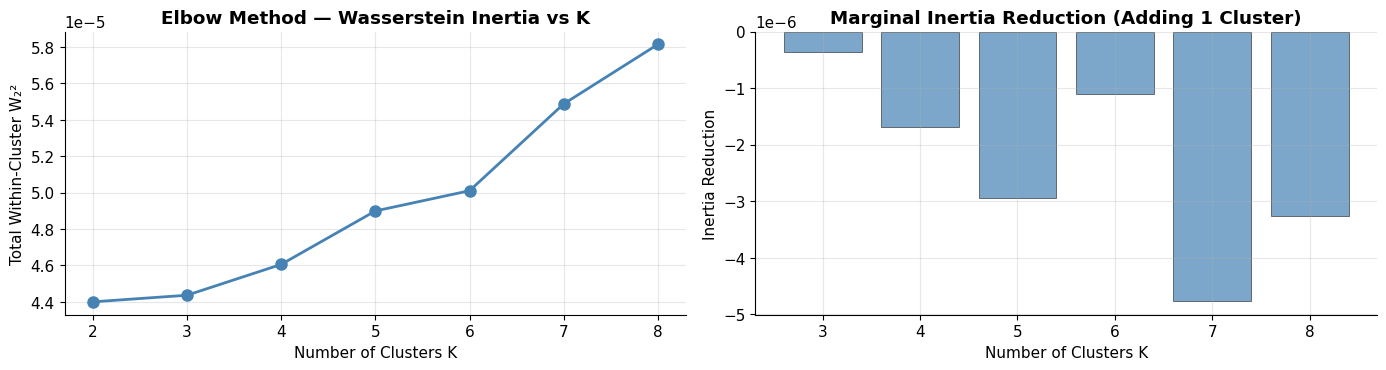


📌 Pick K where the elbow bends — adding more clusters gives little benefit.
   For S&P 500 returns, K=4 or K=5 typically captures the main regimes well.


In [15]:
K_RANGE  = range(2, 9)
inertias = []

print('Running Wasserstein K-Means for K = 2 to 8...')
for k in K_RANGE:
    _, _, inertia = wasserstein_kmeans(quantile_matrix, k=k, n_init=5, seed=42)
    inertias.append(inertia)
    print(f'  K={k}  Inertia={inertia:.6f}')

# ── Elbow plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue', lw=2, markersize=8)
axes[0].set_title('Elbow Method — Wasserstein Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Total Within-Cluster W₂²')
axes[0].set_xticks(list(K_RANGE))

# Marginal improvement
deltas = np.diff(inertias)
axes[1].bar(list(K_RANGE)[1:], -deltas, color='steelblue', alpha=0.7, edgecolor='black', lw=0.5)
axes[1].set_title('Marginal Inertia Reduction (Adding 1 Cluster)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Inertia Reduction')
axes[1].set_xticks(list(K_RANGE)[1:])

plt.tight_layout()
plt.show()

print('\n📌 Pick K where the elbow bends — adding more clusters gives little benefit.')
print('   For S&P 500 returns, K=4 or K=5 typically captures the main regimes well.')

### 4.2 — Fit Final Model with Chosen K

In [16]:
K = 4   # ← Change this based on your elbow plot

print(f'Fitting Wasserstein K-Means with K={K}, 10 restarts...')
labels, centroids, inertia = wasserstein_kmeans(
    quantile_matrix, k=K, n_init=10, seed=42
)
print(f'✅ Done!  Final inertia: {inertia:.6f}')

# Build results dataframe aligned to dates
regime_df = pd.DataFrame({
    'regime':          labels,
    'spy_return':      spy_returns.reindex(window_dates).values,
    'vix':             vix.reindex(window_dates).values,
}, index=window_dates)

# Merge with full returns
for col in returns.columns:
    regime_df[col + '_ret'] = returns[col].reindex(window_dates).values

# Count regime days
counts = pd.Series(labels).value_counts().sort_index()
print(f'\nRegime distribution:')
for r, cnt in counts.items():
    pct = cnt / len(labels) * 100
    print(f'  Regime {r}: {cnt} days ({pct:.1f}%)')

Fitting Wasserstein K-Means with K=4, 10 restarts...
✅ Done!  Final inertia: 0.000046

Regime distribution:
  Regime 0: 619 days (16.7%)
  Regime 1: 1851 days (49.9%)
  Regime 2: 64 days (1.7%)
  Regime 3: 1175 days (31.7%)


---
## 🔬 Module 5 — Analysing the Regime Centroids

Each centroid is a **Wasserstein barycenter** — the average return distribution of all windows in that cluster.  
We visualise the centroid quantile functions to understand what each regime *looks like* distributionally.

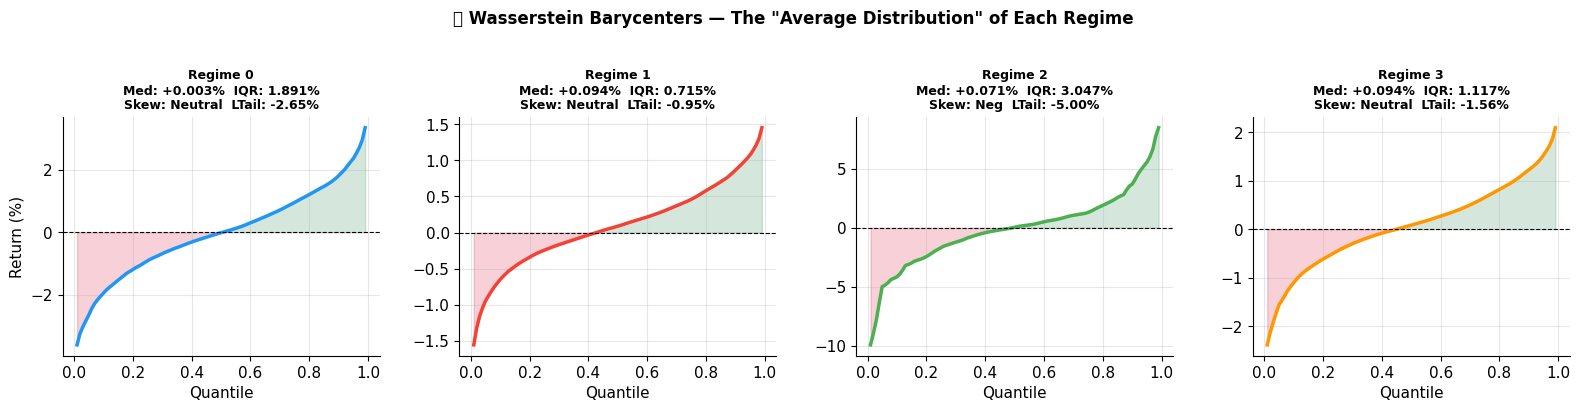


📋 REGIME CENTROID STATISTICS

       Median Return IQR (Vol Proxy) 5th Pct (Left Tail) 95th Pct (Right Tail) Bowley Skewness  N Days
Regime                                                                                                
0            0.0026%         1.8907%            -2.6483%               2.3687%           0.022     619
1            0.0943%         0.7145%            -0.9511%               1.0787%           0.040    1851
2            0.0713%         3.0475%            -4.9970%               5.5763%          -0.173      64
3            0.0938%         1.1172%            -1.5649%               1.5364%           0.021    1175


In [17]:
def characterise_regime(centroid_q, quantile_grid):
    """
    Compute descriptive statistics from a quantile function vector.
    """
    # Median = quantile at 0.5
    median_idx = np.argmin(np.abs(quantile_grid - 0.5))
    median     = centroid_q[median_idx]

    # Spread (IQR as vol proxy)
    q25_idx = np.argmin(np.abs(quantile_grid - 0.25))
    q75_idx = np.argmin(np.abs(quantile_grid - 0.75))
    iqr     = centroid_q[q75_idx] - centroid_q[q25_idx]

    # Left tail (5th percentile)
    q05_idx = np.argmin(np.abs(quantile_grid - 0.05))
    left_tail = centroid_q[q05_idx]

    # Right tail (95th percentile)
    q95_idx = np.argmin(np.abs(quantile_grid - 0.95))
    right_tail = centroid_q[q95_idx]

    # Skewness proxy (Bowley's skewness: robust, quantile-based)
    # S = (Q75 + Q25 - 2*Q50) / (Q75 - Q25)
    bowley_skew = (centroid_q[q75_idx] + centroid_q[q25_idx] - 2 * centroid_q[median_idx]) / iqr

    return {
        'Median Return':  median,
        'IQR (Vol Proxy)': iqr,
        '5th Pct (Left Tail)': left_tail,
        '95th Pct (Right Tail)': right_tail,
        'Bowley Skewness': bowley_skew
    }


# ── Plot all centroid quantile functions ──────────────────────────────────────
fig, axes = plt.subplots(1, K, figsize=(16, 4))
if K == 1:
    axes = [axes]

for j, (ax, centroid) in enumerate(zip(axes, centroids)):
    color = REGIME_COLORS[j]
    stats_j = characterise_regime(centroid, quantile_grid)

    ax.plot(quantile_grid, centroid * 100, lw=2.5, color=color)
    ax.fill_between(quantile_grid, centroid * 100, 0,
                    where=(centroid >= 0), alpha=0.2, color='seagreen')
    ax.fill_between(quantile_grid, centroid * 100, 0,
                    where=(centroid < 0),  alpha=0.2, color='crimson')
    ax.axhline(0, color='black', lw=0.8, linestyle='--')

    skew_str = 'Pos' if stats_j['Bowley Skewness'] > 0.05 else ('Neg' if stats_j['Bowley Skewness'] < -0.05 else 'Neutral')
    ax.set_title(
        f'Regime {j}\n'
        f'Med: {stats_j["Median Return"]*100:+.3f}%  '
        f'IQR: {stats_j["IQR (Vol Proxy)"]*100:.3f}%\n'
        f'Skew: {skew_str}  '
        f'LTail: {stats_j["5th Pct (Left Tail)"]*100:.2f}%',
        fontweight='bold', fontsize=9
    )
    ax.set_xlabel('Quantile')
    ax.set_ylabel('Return (%)' if j == 0 else '')

plt.suptitle('🎯 Wasserstein Barycenters — The "Average Distribution" of Each Regime',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print('\n📋 REGIME CENTROID STATISTICS\n')
summary_rows = []
for j, centroid in enumerate(centroids):
    s = characterise_regime(centroid, quantile_grid)
    s = {k: f'{v*100:.4f}%' if k != 'Bowley Skewness' else f'{v:.3f}' for k, v in s.items()}
    s['Regime'] = j
    s['N Days'] = int((labels == j).sum())
    summary_rows.append(s)
print(pd.DataFrame(summary_rows).set_index('Regime').to_string())

---
## 📅 Module 6 — Regime Timeline

Map the regimes back to calendar time to see which regimes correspond to known market events.

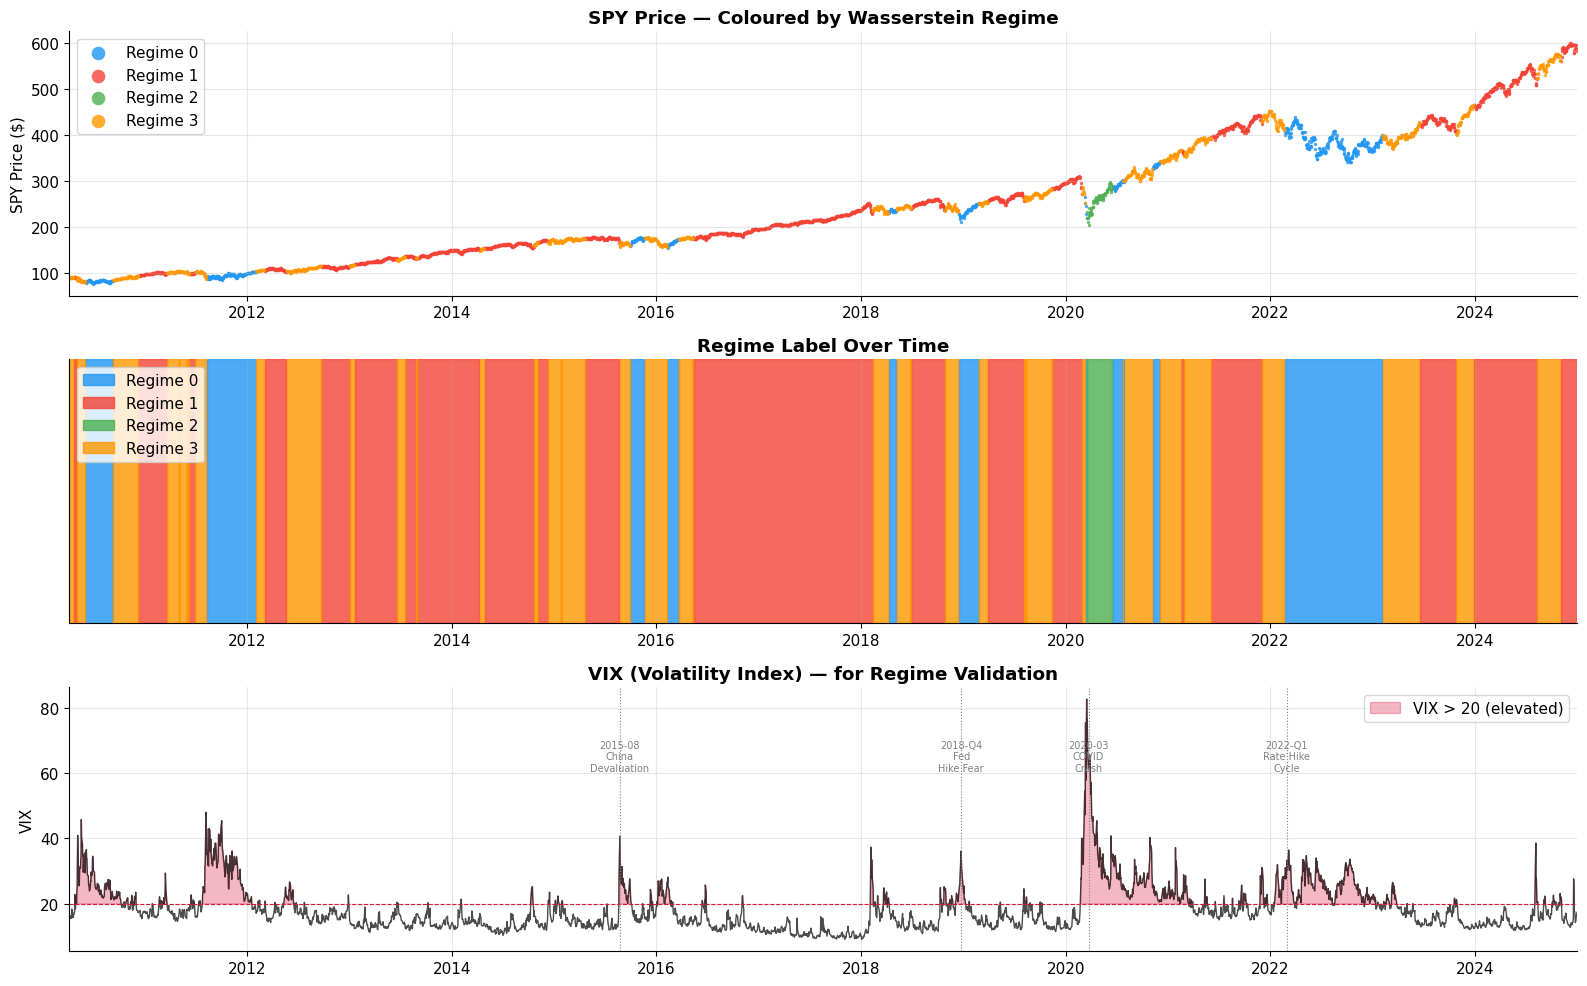

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# ── Panel 1: SPY price coloured by regime ────────────────────────────────────
spy_plot = spy_returns.reindex(window_dates).cumsum()   # approx log-cumulative
spy_price = spy.reindex(window_dates)

for j in range(K):
    mask = labels == j
    axes[0].scatter(window_dates[mask], spy_price.values[mask],
                    c=REGIME_COLORS[j], label=f'Regime {j}',
                    s=6, alpha=0.8, linewidths=0)

axes[0].set_title('SPY Price — Coloured by Wasserstein Regime', fontweight='bold')
axes[0].set_ylabel('SPY Price ($)')
axes[0].legend(markerscale=4, loc='upper left')

# ── Panel 2: Regime label as coloured bands ───────────────────────────────────
for j in range(K):
    mask = labels == j
    axes[1].fill_between(window_dates, 0, 1,
                         where=mask,
                         color=REGIME_COLORS[j], alpha=0.8,
                         label=f'Regime {j}',
                         transform=axes[1].get_xaxis_transform())
axes[1].set_yticks([])
axes[1].set_title('Regime Label Over Time', fontweight='bold')
axes[1].legend(loc='upper left')

# ── Panel 3: VIX ─────────────────────────────────────────────────────────────
vix_plot = vix.reindex(window_dates)
axes[2].plot(window_dates, vix_plot, color='black', lw=1, alpha=0.7)
axes[2].fill_between(window_dates, vix_plot, 20, where=(vix_plot > 20),
                     color='crimson', alpha=0.3, label='VIX > 20 (elevated)')
axes[2].axhline(20, color='crimson', lw=0.8, linestyle='--')
axes[2].set_title('VIX (Volatility Index) — for Regime Validation', fontweight='bold')
axes[2].set_ylabel('VIX')
axes[2].legend()

# Annotate known events
events = {
    '2015-08\nChina\nDevaluation': '2015-08-24',
    '2018-Q4\nFed\nHike Fear':    '2018-12-24',
    '2020-03\nCOVID\nCrash':      '2020-03-23',
    '2022-Q1\nRate Hike\nCycle':  '2022-03-01',
}
for label_text, date_str in events.items():
    try:
        dt = pd.Timestamp(date_str)
        if dt in vix_plot.index or (dt > window_dates[0] and dt < window_dates[-1]):
            axes[2].axvline(dt, color='gray', lw=0.8, linestyle=':')
            axes[2].text(dt, vix_plot.max() * 0.85, label_text,
                         fontsize=7, ha='center', va='top', color='gray')
    except:
        pass

for ax in axes:
    ax.set_xlim(window_dates[0], window_dates[-1])

plt.tight_layout()
plt.show()

---
## 📐 Module 7 — Performance Analytics by Regime

Now we answer: **what actually happens in each regime?**  
We compute key risk/return metrics conditional on regime membership.


📋 REGIME PERFORMANCE STATISTICS (SPY)

        N Days Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Hit Rate Avg VIX Skewness Excess Kurt
Regime                                                                                                    
0          619       18.9%           25.1%         0.75       -23.6%    52.3%   25.34    -0.69        7.11
1         1851        8.3%           11.7%         0.71       -15.1%    55.6%   14.66    -0.90        3.51
2           64      115.7%           41.6%         2.78       -11.3%    60.9%   40.00     0.38        1.41
3         1175       15.4%           16.7%         0.92       -17.3%    55.4%   19.29    -0.72        5.45


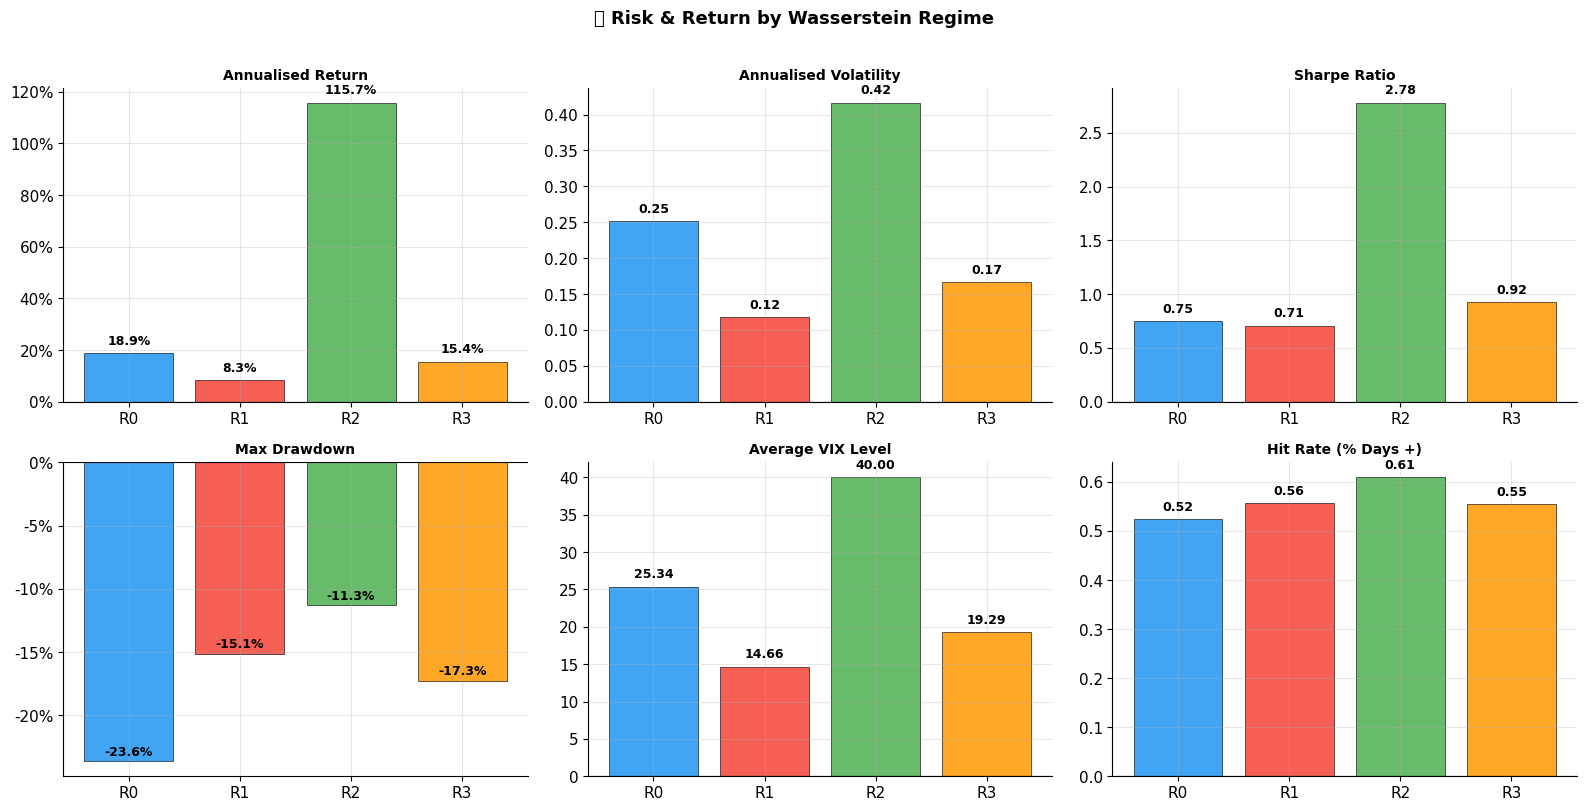

In [19]:
def sharpe(r, periods=252):
    r = pd.Series(r).dropna()
    return (r.mean() / r.std()) * np.sqrt(periods) if r.std() > 0 else 0

def max_dd(r):
    r  = pd.Series(r).dropna()
    c  = (1 + r).cumprod()
    return ((c - c.cummax()) / c.cummax()).min()


# Compute regime statistics
regime_stats = []
for j in range(K):
    mask = labels == j
    r    = regime_df.loc[mask, 'spy_return']
    v    = regime_df.loc[mask, 'vix']

    regime_stats.append({
        'Regime':          j,
        'N Days':          mask.sum(),
        'Ann. Return':     r.mean() * 252,
        'Ann. Volatility': r.std() * np.sqrt(252),
        'Sharpe Ratio':    sharpe(r),
        'Max Drawdown':    max_dd(r),
        'Hit Rate':        (r > 0).mean(),
        'Avg VIX':         v.mean(),
        'Skewness':        stats.skew(r.dropna()),
        'Excess Kurt':     stats.kurtosis(r.dropna()),
    })

regime_stats_df = pd.DataFrame(regime_stats).set_index('Regime')

# Format for display
display_df = regime_stats_df.copy()
for col in ['Ann. Return', 'Ann. Volatility', 'Max Drawdown', 'Hit Rate']:
    display_df[col] = display_df[col].map('{:.1%}'.format)
for col in ['Sharpe Ratio', 'Avg VIX', 'Skewness', 'Excess Kurt']:
    display_df[col] = display_df[col].map('{:.2f}'.format)

print('\n📋 REGIME PERFORMANCE STATISTICS (SPY)\n')
print(display_df.to_string())

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

metrics = [
    ('Ann. Return',     'Annualised Return',  True),
    ('Ann. Volatility', 'Annualised Volatility', False),
    ('Sharpe Ratio',    'Sharpe Ratio',       False),
    ('Max Drawdown',    'Max Drawdown',        True),
    ('Avg VIX',         'Average VIX Level',   False),
    ('Hit Rate',        'Hit Rate (% Days +)', False),
]

for ax, (col, title, is_pct) in zip(axes, metrics):
    vals = regime_stats_df[col]
    bars = ax.bar(
        [f'R{j}' for j in range(K)], vals,
        color=REGIME_COLORS[:K], alpha=0.85,
        edgecolor='black', linewidth=0.5
    )
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(title, fontweight='bold', fontsize=10)
    if is_pct:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    for bar, val in zip(bars, vals):
        fmt = f'{val:.1%}' if is_pct else f'{val:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + abs(vals.max()) * 0.02,
                fmt, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('📊 Risk & Return by Wasserstein Regime', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 7.1 — Full Distribution of Returns by Regime

This is what makes Wasserstein clustering powerful — each regime has a **distinct distributional shape**, not just a different mean/vol.

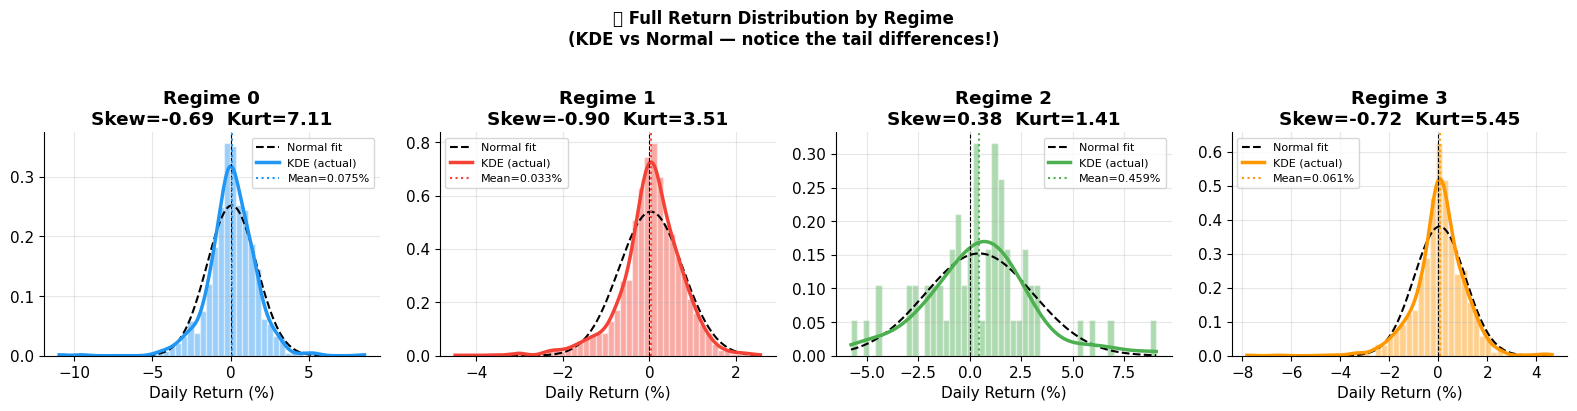

📌 KEY INSIGHT: The black dashed Normal curve often misses the actual tails.
   Wasserstein clustering captures THESE differences — not just mean/vol.


In [20]:
fig, axes = plt.subplots(1, K, figsize=(16, 4), sharey=False)
if K == 1:
    axes = [axes]

for j, ax in enumerate(axes):
    mask   = labels == j
    r      = regime_df.loc[mask, 'spy_return'].dropna() * 100
    color  = REGIME_COLORS[j]

    # KDE-smoothed histogram
    ax.hist(r, bins=50, density=True, alpha=0.45, color=color, edgecolor='white', lw=0.2)

    # Normal fit for comparison
    mu_j, sig_j = r.mean(), r.std()
    x = np.linspace(r.min(), r.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu_j, sig_j), 'k--', lw=1.5, label='Normal fit')

    # KDE fit (actual shape)
    kde = stats.gaussian_kde(r.values)
    ax.plot(x, kde(x), color=color, lw=2.5, label='KDE (actual)')

    ax.axvline(0,    color='black', lw=0.8, linestyle='--')
    ax.axvline(mu_j, color=color,  lw=1.5, linestyle=':', label=f'Mean={mu_j:.3f}%')

    sk = stats.skew(r)
    ku = stats.kurtosis(r)
    ax.set_title(f'Regime {j}\nSkew={sk:.2f}  Kurt={ku:.2f}', fontweight='bold')
    ax.set_xlabel('Daily Return (%)')
    ax.legend(fontsize=8)

plt.suptitle('📊 Full Return Distribution by Regime\n(KDE vs Normal — notice the tail differences!)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('📌 KEY INSIGHT: The black dashed Normal curve often misses the actual tails.')
print('   Wasserstein clustering captures THESE differences — not just mean/vol.')

---
## 🔄 Module 8 — Regime Transition Matrix (Markov Analysis)

Markets don't jump randomly between regimes — they tend to **persist** in a regime for a while, then transition.

The **transition matrix** $P$ where $P_{ij}$ = probability of moving from regime $i$ to regime $j$ tomorrow.  
This is the **first-order Markov approximation** of regime dynamics.

Reference: Hamilton, J.D. (1989). *A New Approach to the Economic Analysis of Nonstationary Time Series*. Econometrica.


🔄 TRANSITION MATRIX  P[i→j] = P(next regime = j | current = i)

         To R0  To R1  To R2  To R3
From R0  0.982  0.000  0.002  0.016
From R1  0.000  0.985  0.000  0.015
From R2  0.016  0.000  0.984  0.000
From R3  0.009  0.025  0.000  0.967

⏱️  AVERAGE REGIME DURATION
  Regime 0: 56.3 consecutive days
  Regime 1: 63.8 consecutive days
  Regime 2: 64.0 consecutive days
  Regime 3: 30.1 consecutive days


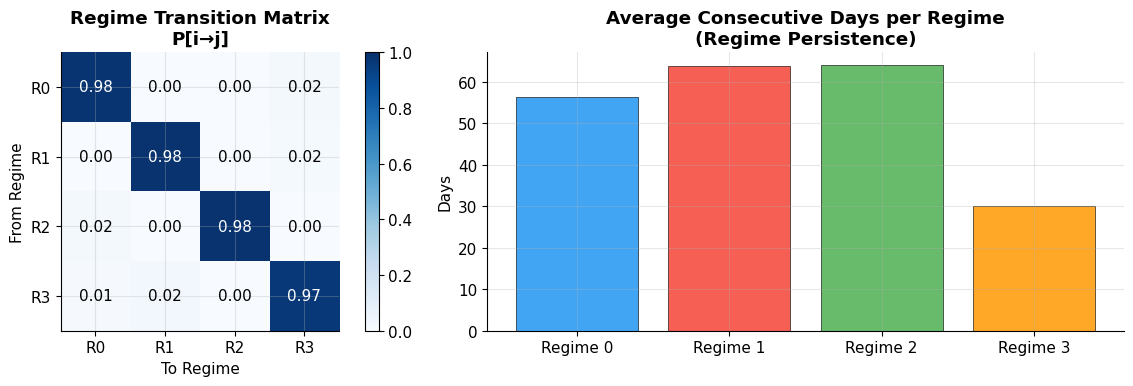


📌 High diagonal values → regimes are persistent (sticky).
   Low diagonal → frequent transitions (unstable regime classification).


In [21]:
def transition_matrix(labels, k):
    """
    Compute empirical first-order Markov transition matrix.
    T[i,j] = P(regime_t+1 = j | regime_t = i)
    """
    T = np.zeros((k, k))
    for t in range(len(labels) - 1):
        T[labels[t], labels[t + 1]] += 1
    # Normalise rows to probabilities
    row_sums = T.sum(axis=1, keepdims=True)
    T = np.divide(T, row_sums, where=row_sums > 0)
    return T


def regime_durations(labels, k):
    """Compute average consecutive days spent in each regime."""
    durations = {j: [] for j in range(k)}
    current, count = labels[0], 1
    for lab in labels[1:]:
        if lab == current:
            count += 1
        else:
            durations[current].append(count)
            current, count = lab, 1
    durations[current].append(count)
    return {j: np.mean(v) for j, v in durations.items() if v}


T  = transition_matrix(labels, K)
dur = regime_durations(labels, K)

print('\n🔄 TRANSITION MATRIX  P[i→j] = P(next regime = j | current = i)\n')
T_df = pd.DataFrame(T,
                     index=[f'From R{j}' for j in range(K)],
                     columns=[f'To R{j}' for j in range(K)])
print(T_df.round(3).to_string())

print('\n⏱️  AVERAGE REGIME DURATION')
for j, d in dur.items():
    print(f'  Regime {j}: {d:.1f} consecutive days')

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im = axes[0].imshow(T, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].set_xticks(range(K)); axes[0].set_xticklabels([f'R{j}' for j in range(K)])
axes[0].set_yticks(range(K)); axes[0].set_yticklabels([f'R{j}' for j in range(K)])
axes[0].set_title('Regime Transition Matrix\nP[i→j]', fontweight='bold')
axes[0].set_xlabel('To Regime')
axes[0].set_ylabel('From Regime')
for i in range(K):
    for j in range(K):
        axes[0].text(j, i, f'{T[i,j]:.2f}',
                     ha='center', va='center', fontsize=11,
                     color='white' if T[i,j] > 0.5 else 'black')

# Average durations
axes[1].bar([f'Regime {j}' for j in dur.keys()], dur.values(),
            color=REGIME_COLORS[:K], alpha=0.85, edgecolor='black', lw=0.5)
axes[1].set_title('Average Consecutive Days per Regime\n(Regime Persistence)', fontweight='bold')
axes[1].set_ylabel('Days')

plt.tight_layout()
plt.show()

print('\n📌 High diagonal values → regimes are persistent (sticky).')
print('   Low diagonal → frequent transitions (unstable regime classification).')

---
## 🔮 Module 9 — Forward Return Analysis

Knowing the current regime is only useful if it **predicts future returns**.  
We compute forward SPY returns over 1, 5, 21, and 63-day horizons, conditional on each regime.


📅 MEAN FORWARD RETURNS BY REGIME

              Regime 0   Regime 1    Regime 2   Regime 3
1d Forward      +0.09%    +0.03%*      +0.37%   +0.06%**
5d Forward   +0.45%***  +0.20%***   +2.33%***  +0.21%***
21d Forward  +1.93%***  +0.85%***   +7.16%***  +1.16%***
63d Forward  +4.16%***  +2.59%***  +16.34%***  +4.75%***

  *** p<1%  ** p<5%  * p<10%  (t-test: mean return ≠ 0)


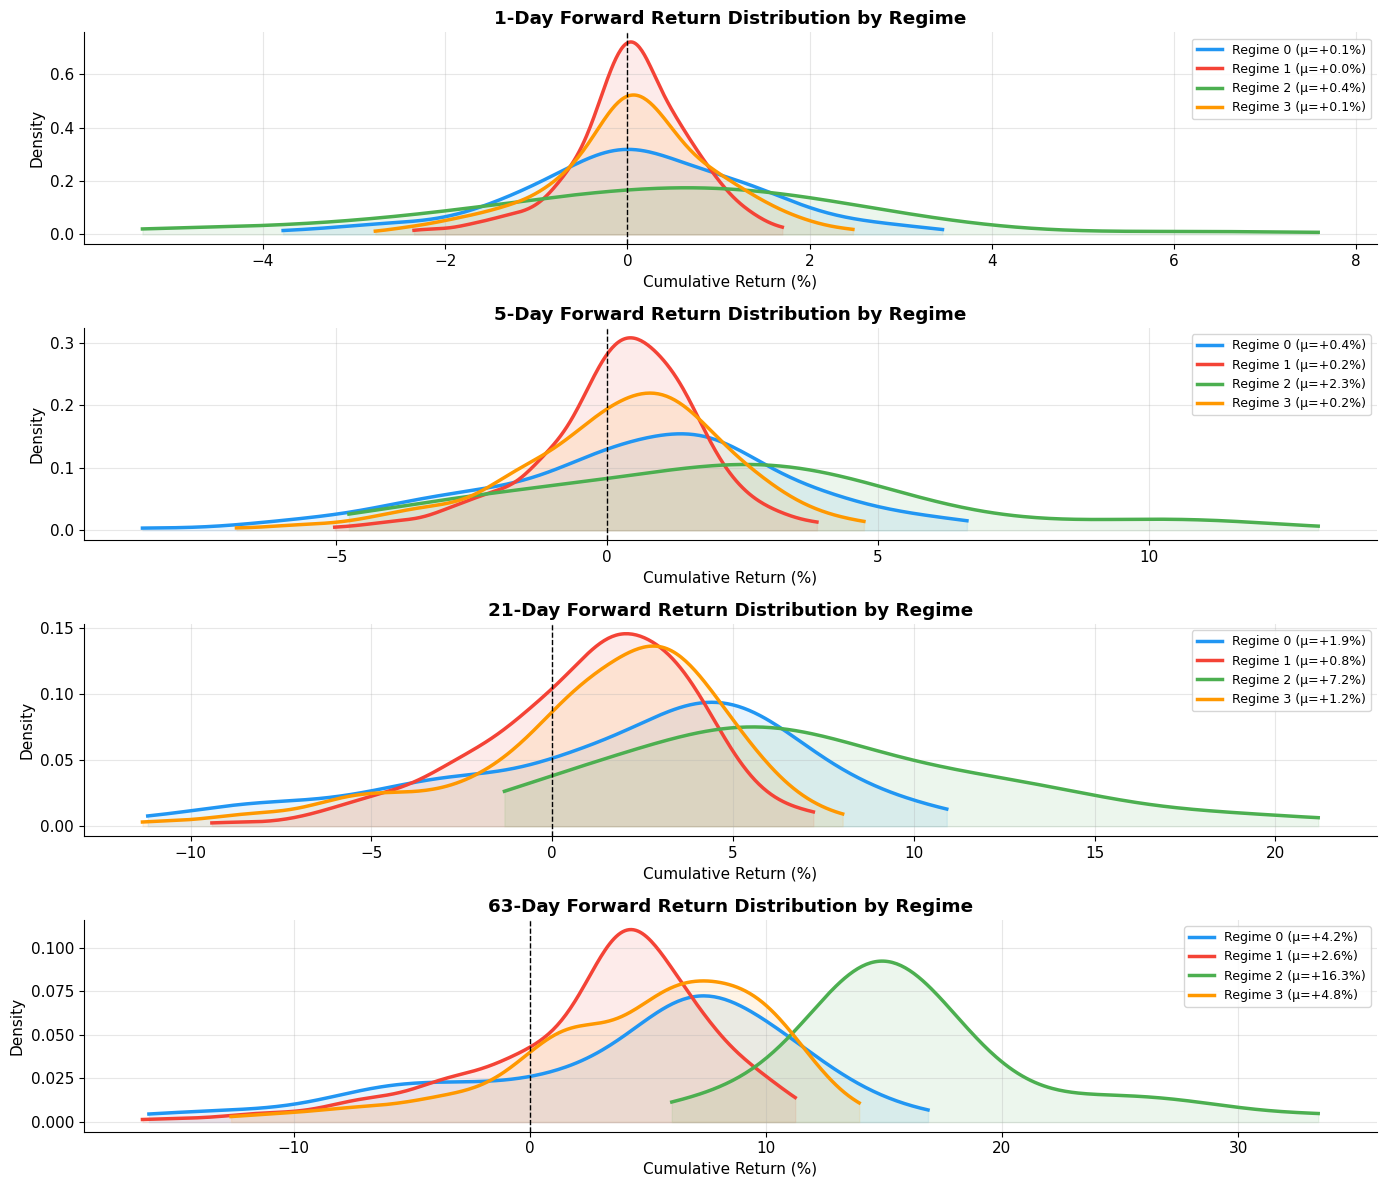

In [22]:
HORIZONS = [1, 5, 21, 63]

# Compute forward returns for each horizon
spy_series = spy_returns.reindex(window_dates)
fwd_data   = {}

for h in HORIZONS:
    fwd = spy_series.shift(-h).rolling(h).sum()   # cumulative forward return
    fwd_data[h] = fwd.values

# Mean forward return and t-stat by regime
print('\n📅 MEAN FORWARD RETURNS BY REGIME\n')
fwd_table = {}
for h in HORIZONS:
    row = {}
    for j in range(K):
        mask   = labels == j
        fwd_r  = fwd_data[h][mask]
        fwd_r  = fwd_r[~np.isnan(fwd_r)]
        mean_r = np.mean(fwd_r)
        t_stat, p_val = stats.ttest_1samp(fwd_r, 0) if len(fwd_r) > 2 else (0, 1)
        sig = '***' if p_val < 0.01 else ('**' if p_val < 0.05 else ('*' if p_val < 0.10 else ''))
        row[f'Regime {j}'] = f'{mean_r:+.2%}{sig}'
    fwd_table[f'{h}d Forward'] = row

print(pd.DataFrame(fwd_table).T.to_string())
print('\n  *** p<1%  ** p<5%  * p<10%  (t-test: mean return ≠ 0)')

# ── Plot forward return distributions ────────────────────────────────────────
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(14, 3 * len(HORIZONS)))

for ax, h in zip(axes, HORIZONS):
    for j in range(K):
        mask  = labels == j
        fwd_r = fwd_data[h][mask]
        fwd_r = fwd_r[~np.isnan(fwd_r)] * 100
        if len(fwd_r) > 5:
            kde = stats.gaussian_kde(fwd_r)
            x   = np.linspace(np.percentile(fwd_r, 1), np.percentile(fwd_r, 99), 300)
            ax.plot(x, kde(x), lw=2.5, color=REGIME_COLORS[j], label=f'Regime {j} (μ={fwd_r.mean():+.1f}%)')
            ax.fill_between(x, kde(x), 0, alpha=0.1, color=REGIME_COLORS[j])
    ax.axvline(0, color='black', lw=1, linestyle='--')
    ax.set_title(f'{h}-Day Forward Return Distribution by Regime', fontweight='bold')
    ax.set_xlabel('Cumulative Return (%)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 🌐 Module 10 — Multivariate Extension: Sliced Wasserstein Distance

So far we clustered on SPY returns alone (1D).  
Real markets are **multivariate** — we want to cluster on the joint distribution of multiple assets simultaneously.

### The Problem

In 2D+, the closed-form Wasserstein formula no longer applies.  
Full optimal transport in d dimensions requires solving a linear program — expensive for large datasets.

### The Solution: Sliced Wasserstein Distance

**Sliced Wasserstein** (Rabin et al., 2012) projects the multivariate distribution onto many random **1D directions** (slices), computes the cheap 1D Wasserstein distance on each slice, then averages:

$$SW_2(\mu, \nu) = \left( \int_{S^{d-1}} W_2(\theta_\# \mu,\, \theta_\# \nu)^2 \, d\sigma(\theta) \right)^{1/2}$$

where $\theta_\# \mu$ is the projection of $\mu$ onto direction $\theta \in S^{d-1}$.

This gives a **proper metric** on multivariate distributions and scales to high dimensions.

Reference: Bonneel et al. (2015). *Sliced and Radon Wasserstein Barycenters of Measures*. JMIV.

In [23]:
def sliced_wasserstein_distance(X, Y, n_projections=200, seed=0):
    """
    Sliced Wasserstein-2 distance between two multivariate sample sets.

    For each random projection direction θ:
      1. Project X → x_θ = X @ θ   (1D samples)
      2. Project Y → y_θ = Y @ θ
      3. Compute W2(x_θ, y_θ) via sorted arrays (1D closed form)
    Return: sqrt(mean over all directions of W2²)

    Reference: Rabin et al. (2012). Wasserstein Barycenter and Its Application
               to Texture Mixing.
    """
    rng = np.random.default_rng(seed)
    d   = X.shape[1]

    # Sample random directions on the unit sphere
    thetas = rng.standard_normal((n_projections, d))
    thetas /= np.linalg.norm(thetas, axis=1, keepdims=True)

    sw2_sq = 0.0
    for theta in thetas:
        # Project both samples onto this direction
        proj_X = X @ theta
        proj_Y = Y @ theta

        # W2 in 1D: sort both, compute L2 (equal-weight assumption)
        n = min(len(proj_X), len(proj_Y))
        pX = np.sort(np.random.choice(proj_X, n, replace=False))
        pY = np.sort(np.random.choice(proj_Y, n, replace=False))
        sw2_sq += np.mean((pX - pY) ** 2)

    return np.sqrt(sw2_sq / n_projections)


# ── Build multivariate windows ────────────────────────────────────────────────
# Each window = (WINDOW x n_assets) matrix of returns
ASSETS = list(returns.columns)   # SPY, TLT, GLD, HYG
ret_arr = returns[ASSETS].values

print(f'Building multivariate windows ({WINDOW}-day, {len(ASSETS)} assets)...')
print(f'Computing pairwise Sliced Wasserstein distances...')
print('(This uses a subsample for speed — increase n_sub for more precision)')

# Subsample windows for the pairwise distance matrix (full matrix is expensive)
n_sub = min(300, len(window_dates))
sub_idx  = np.linspace(0, len(window_dates) - 1, n_sub, dtype=int)
sub_dates = window_dates[sub_idx]

# Build list of multivariate samples for each subsampled window
mv_windows = []
for i in sub_idx:
    start_i = i  # window_dates[i] is end of the window
    # Find position in ret_arr
    end_pos = returns.index.get_indexer([window_dates[i]], method='nearest')[0]
    w = ret_arr[max(0, end_pos - WINDOW): end_pos]
    if len(w) == WINDOW:
        mv_windows.append(w)
    else:
        mv_windows.append(np.zeros((WINDOW, len(ASSETS))))

mv_windows = np.array(mv_windows)   # shape: (n_sub, WINDOW, n_assets)

# Compute pairwise SW distances (symmetric)
n  = len(mv_windows)
SW = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        d = sliced_wasserstein_distance(mv_windows[i], mv_windows[j], n_projections=50)
        SW[i, j] = d
        SW[j, i] = d
    if i % 50 == 0:
        print(f'  Progress: {i}/{n} windows processed...')

print('✅ Sliced Wasserstein distance matrix computed!')
print(f'   Shape: {SW.shape}')

Building multivariate windows (63-day, 4 assets)...
Computing pairwise Sliced Wasserstein distances...
(This uses a subsample for speed — increase n_sub for more precision)
  Progress: 0/300 windows processed...
  Progress: 50/300 windows processed...
  Progress: 100/300 windows processed...
  Progress: 150/300 windows processed...
  Progress: 200/300 windows processed...
  Progress: 250/300 windows processed...
✅ Sliced Wasserstein distance matrix computed!
   Shape: (300, 300)


Embedding via MDS...


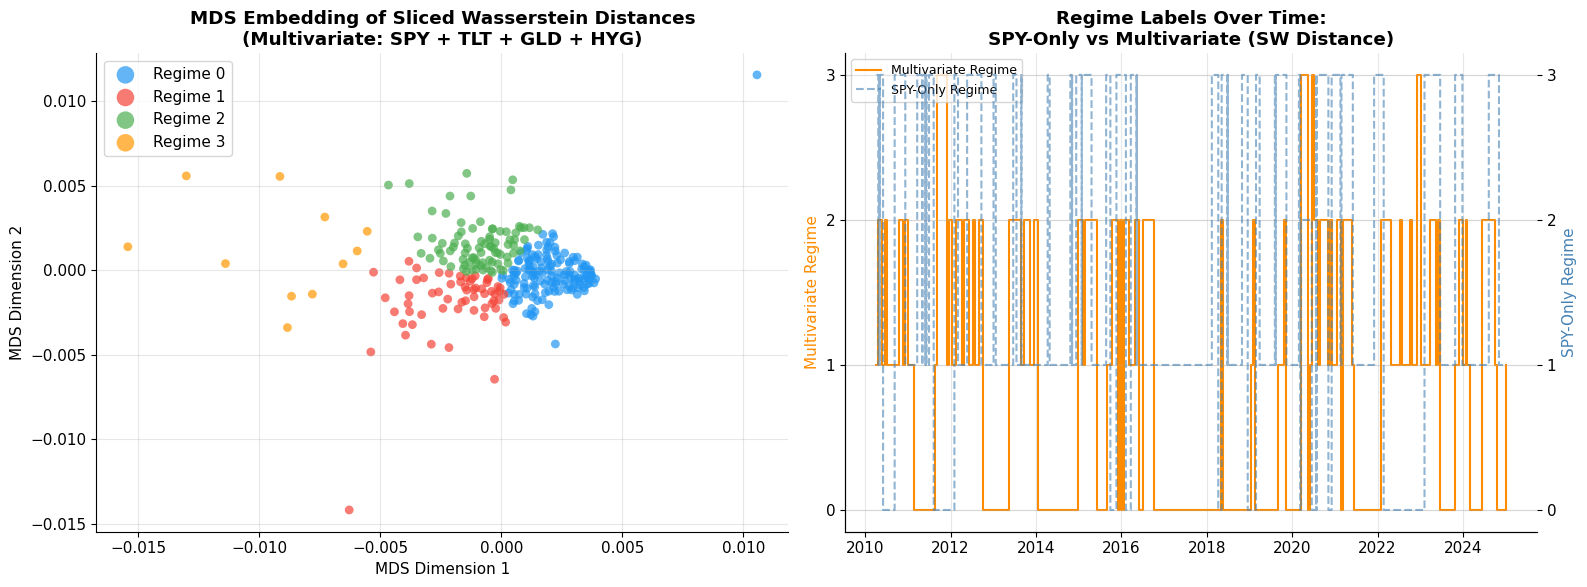

📌 KEY INSIGHT: When multivariate and SPY-only regimes agree, the signal is stronger.
   Divergences suggest cross-asset dynamics (e.g. equity-bond correlation shifts) matter.


In [24]:
from sklearn.manifold import MDS
from sklearn.cluster import KMeans

# ── Embed via MDS (preserve pairwise SW distances) ───────────────────────────
# Multidimensional Scaling: find 2D coordinates that best preserve SW distances
print('Embedding via MDS...')
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=4)
embedding = mds.fit_transform(SW)

# ── Cluster in the MDS embedding space ───────────────────────────────────────
km_mv = KMeans(n_clusters=K, random_state=42, n_init=10)
mv_labels = km_mv.fit_predict(embedding)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MDS scatter coloured by multivariate regime
for j in range(K):
    mask = mv_labels == j
    axes[0].scatter(embedding[mask, 0], embedding[mask, 1],
                    color=REGIME_COLORS[j], label=f'Regime {j}',
                    s=40, alpha=0.7, edgecolors='none')
axes[0].set_title(
    'MDS Embedding of Sliced Wasserstein Distances\n'
    f'(Multivariate: {" + ".join(ASSETS)})',
    fontweight='bold'
)
axes[0].set_xlabel('MDS Dimension 1')
axes[0].set_ylabel('MDS Dimension 2')
axes[0].legend(markerscale=2)

# Compare 1D (SPY) vs Multivariate regime labels over time
# Map sub-sampled multivariate labels back to dates
mv_label_series = pd.Series(mv_labels, index=sub_dates)
spy_label_series = pd.Series(labels, index=window_dates)

ax2 = axes[1]
ax2_twin = ax2.twinx()

ax2.step(sub_dates, mv_labels, where='post',
         color='darkorange', lw=1.5, label='Multivariate Regime')
ax2_twin.step(window_dates, labels, where='post',
              color='steelblue', lw=1.5, linestyle='--', label='SPY-Only Regime', alpha=0.6)

ax2.set_title('Regime Labels Over Time:\nSPY-Only vs Multivariate (SW Distance)', fontweight='bold')
ax2.set_ylabel('Multivariate Regime', color='darkorange')
ax2_twin.set_ylabel('SPY-Only Regime', color='steelblue')
ax2.set_yticks(range(K))
ax2_twin.set_yticks(range(K))

lines1, labs1 = ax2.get_legend_handles_labels()
lines2, labs2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labs1 + labs2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print('📌 KEY INSIGHT: When multivariate and SPY-only regimes agree, the signal is stronger.')
print('   Divergences suggest cross-asset dynamics (e.g. equity-bond correlation shifts) matter.')

---
## 🏁 Module 11 — Final Dashboard

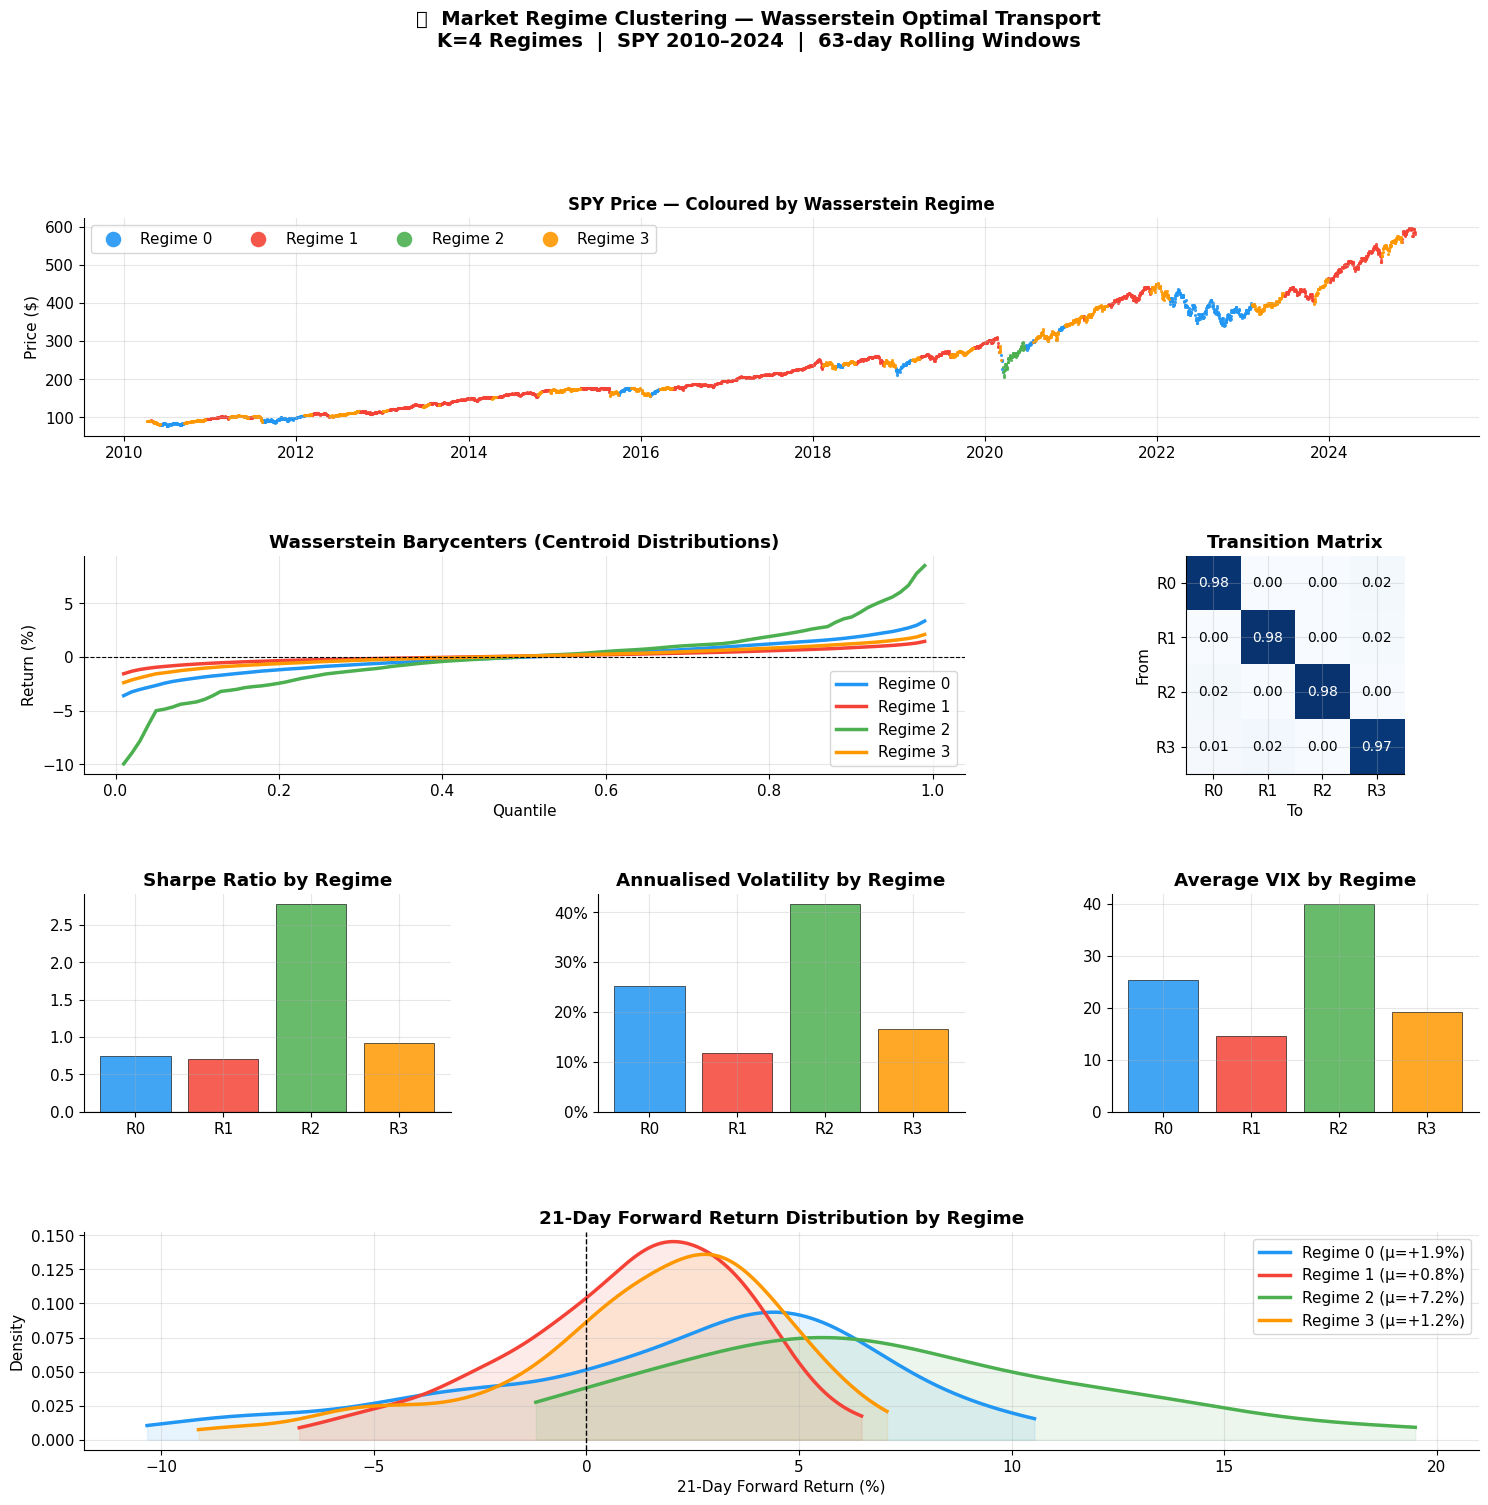

In [25]:
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.4)

# ── 1. SPY price coloured by regime (full width) ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
spy_p = spy.reindex(window_dates)
for j in range(K):
    mask = labels == j
    ax1.scatter(window_dates[mask], spy_p.values[mask],
                c=REGIME_COLORS[j], s=5, alpha=0.9, label=f'Regime {j}', linewidths=0)
ax1.set_title('SPY Price — Coloured by Wasserstein Regime', fontweight='bold', fontsize=12)
ax1.set_ylabel('Price ($)')
ax1.legend(markerscale=5, ncol=K)

# ── 2. Centroid quantile functions ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
for j, centroid in enumerate(centroids):
    ax2.plot(quantile_grid, centroid * 100, lw=2.5,
             color=REGIME_COLORS[j], label=f'Regime {j}')
ax2.axhline(0, color='black', lw=0.8, linestyle='--')
ax2.set_title('Wasserstein Barycenters (Centroid Distributions)', fontweight='bold')
ax2.set_xlabel('Quantile')
ax2.set_ylabel('Return (%)')
ax2.legend()

# ── 3. Transition matrix heatmap ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
im  = ax3.imshow(T, cmap='Blues', vmin=0, vmax=1)
ax3.set_xticks(range(K)); ax3.set_xticklabels([f'R{j}' for j in range(K)])
ax3.set_yticks(range(K)); ax3.set_yticklabels([f'R{j}' for j in range(K)])
for i in range(K):
    for j in range(K):
        ax3.text(j, i, f'{T[i,j]:.2f}', ha='center', va='center', fontsize=10,
                 color='white' if T[i,j] > 0.5 else 'black')
ax3.set_title('Transition Matrix', fontweight='bold')
ax3.set_xlabel('To'); ax3.set_ylabel('From')

# ── 4. Sharpe by regime ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
vals = regime_stats_df['Sharpe Ratio']
ax4.bar([f'R{j}' for j in range(K)], vals, color=REGIME_COLORS[:K], alpha=0.85, edgecolor='black', lw=0.5)
ax4.axhline(0, color='black', lw=0.8)
ax4.set_title('Sharpe Ratio by Regime', fontweight='bold')

# ── 5. Volatility by regime ───────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
vals = regime_stats_df['Ann. Volatility']
ax5.bar([f'R{j}' for j in range(K)], vals, color=REGIME_COLORS[:K], alpha=0.85, edgecolor='black', lw=0.5)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax5.set_title('Annualised Volatility by Regime', fontweight='bold')

# ── 6. Avg VIX by regime ──────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
vals = regime_stats_df['Avg VIX']
ax6.bar([f'R{j}' for j in range(K)], vals, color=REGIME_COLORS[:K], alpha=0.85, edgecolor='black', lw=0.5)
ax6.set_title('Average VIX by Regime', fontweight='bold')

# ── 7. Forward 21d return by regime ──────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, :])
for j in range(K):
    mask  = labels == j
    fwd_r = fwd_data[21][mask]
    fwd_r = fwd_r[~np.isnan(fwd_r)] * 100
    if len(fwd_r) > 5:
        kde = stats.gaussian_kde(fwd_r)
        x   = np.linspace(np.percentile(fwd_r, 2), np.percentile(fwd_r, 98), 300)
        ax7.plot(x, kde(x), lw=2.5, color=REGIME_COLORS[j],
                 label=f'Regime {j} (μ={fwd_r.mean():+.1f}%)')
        ax7.fill_between(x, kde(x), 0, alpha=0.1, color=REGIME_COLORS[j])
ax7.axvline(0, color='black', lw=1, linestyle='--')
ax7.set_title('21-Day Forward Return Distribution by Regime', fontweight='bold')
ax7.set_xlabel('21-Day Forward Return (%)')
ax7.set_ylabel('Density')
ax7.legend()

fig.suptitle(
    '🗺️  Market Regime Clustering — Wasserstein Optimal Transport\n'
    f'K={K} Regimes  |  SPY 2010–2024  |  63-day Rolling Windows',
    fontsize=14, fontweight='bold', y=1.01
)
plt.show()

---
## 📚 Summary — What You Built

| Component | What It Does | Academic Reference |
|---|---|---|
| **Rolling Quantile Functions** | Represent each window as a full distribution | Empirical process theory |
| **Wasserstein-2 Distance** | Closed-form metric between 1D distributions | Villani (2008) |
| **K-Means++ Init** | Spread initial centroids to avoid local minima | Arthur & Vassilvitskii (2007) |
| **Wasserstein Barycenter** | Centroid in distribution space = mean of quantile functions | Agueh & Carlier (2011) |
| **Elbow Method** | Choose K via inertia curve | Standard model selection |
| **Markov Transition Matrix** | Model regime persistence and switching | Hamilton (1989) |
| **Forward Return Analysis** | Test predictive power of each regime | Out-of-sample validation |
| **Sliced Wasserstein** | Extend to multivariate distributions cheaply | Rabin et al. (2012) |
| **MDS Embedding** | Visualise SW distance geometry in 2D | Torgerson (1952) |

---

## 🚀 Next Steps

1. **Try different assets** — replace `TICKERS` with any Yahoo Finance symbols
2. **Try different window lengths** — `WINDOW = 21` (monthly) or `WINDOW = 126` (semi-annual)
3. **Add Sinkhorn regularisation** — use `ot.sinkhorn` for faster approximate OT
4. **Hidden Markov Models** — replace K-Means with a probabilistic HMM regime model
5. **Regime-conditional strategy** — only trade in regimes with high forward Sharpe
6. **Walk-forward validation** — train on first 5 years, test on remaining years
7. **Wasserstein gradient flows** — explore how distributions evolve between regimes continuously

---

## 📖 Key References

- Villani, C. (2008). *Optimal Transport: Old and New*. Springer-Verlag.
- Agueh, M. & Carlier, G. (2011). *Barycenters in the Wasserstein Space*. SIAM J. Math. Analysis.
- Rabin, J. et al. (2012). *Wasserstein Barycenter and Its Application to Texture Mixing*. LNCS.
- Bonneel, N. et al. (2015). *Sliced and Radon Wasserstein Barycenters of Measures*. JMIV.
- Arthur, D. & Vassilvitskii, S. (2007). *k-means++: The Advantages of Careful Seeding*. SODA.
- Hamilton, J.D. (1989). *A New Approach to the Economic Analysis of Nonstationary Time Series*. Econometrica.
- Marti, G. et al. (2021). *A Review of Correlations, Hierarchies, Networks and Clustering in Financial Markets*. Springer.

